# FlightRisk NYC — walkthrough

Predicting whether a flight leaving JFK, LGA or EWR will arrive more than 15
minutes late, **at the scheduled departure time, before push-back**.

This notebook runs the same code paths as the command-line pipeline. Run
`make reproduce` first so the cached splits and fitted models exist.

## 1. Load the raw tables

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np, pandas as pd
from IPython.display import Image, display

from src.data_loader import load_tables

tables = load_tables()
pd.DataFrame({
    "table": list(tables),
    "rows": [len(t) for t in tables.values()],
    "columns": [t.shape[1] for t in tables.values()],
})

,table,rows,columns
0,flights,336776,19
1,weather,26115,15
2,planes,3322,9
3,airports,1458,8
4,airlines,16,2


In [2]:
tables["flights"].head(3)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z


## 2. The decision that defines the project

`dep_delay` is in the flights table and correlates with `arr_delay` at about
0.9. It is also unknown until the aircraft actually moves, so a model that uses
it cannot inform any pre-departure decision.

In [3]:
f = tables["flights"].dropna(subset=["arr_delay", "dep_delay"])
print(f"correlation of dep_delay with arr_delay: {f.dep_delay.corr(f.arr_delay):.3f}")
print(f"share of flights arriving >15 min late:  {(f.arr_delay > 15).mean():.1%}")

correlation of dep_delay with arr_delay: 0.915
share of flights arriving >15 min late:  23.7%


## 3. Build the features and the temporal split

In [4]:
from src.pipeline import load_splits, xy
from src.config import MODE_A, MODE_B

train, valid, test, manifest = load_splits()
pd.DataFrame({
    "split": ["train (Jan-Aug)", "valid (Sep-Oct)", "test (Nov-Dec)"],
    "flights": [len(train), len(valid), len(test)],
    "late rate": [f"{d.is_delayed.mean():.1%}" for d in (train, valid, test)],
})

,split,flights,late rate
0,train (Jan-Aug),217727,25.6%
1,valid (Sep-Oct),55628,15.1%
2,test (Nov-Dec),53991,25.0%


The validation base rate sits ten points below both neighbours. That is
not a mistake in the split — September and October 2013 really were unusually
smooth — and it drives the calibration result in section 8.

In [5]:
feats = manifest["features"][MODE_A]
print(f"{len(feats)} pre-flight features")
from src.explain import feature_groups
for name, cols in feature_groups(feats).items():
    print(f"  {name:18s} {len(cols):2d}  e.g. {', '.join(cols[:3])}")

67 pre-flight features


  weather            17  e.g. wx_dewp, wx_freezing, wx_humid
  historical rates    8  e.g. te_carrier, te_dest, te_route
  congestion          7  e.g. origin_hour_deps, origin_slot15_deps, origin_day_deps
  rotation            5  e.g. rotation_gap_min, rotation_slack_min, is_tight_turn
  calendar           12  e.g. month, day_of_week, day_of_year
  aircraft            6  e.g. plane_age, engines, seats
  route & schedule   12  e.g. distance, sched_block_min, block_slack_min


### Leakage checks

These run as `pytest tests -q`. The two that matter most: the inbound-leg
delay must never come from the future, and the tail-number target encoding must
be genuinely out-of-fold.

In [6]:
from sklearn.metrics import roc_auc_score
from src.config import LEAKY_COLUMNS, GATE_ONLY_FEATURES

assert not set(LEAKY_COLUMNS) & set(feats)
assert not set(GATE_ONLY_FEATURES) & set(feats)
auc = roc_auc_score(train.is_delayed, train.te_tailnum)
print(f"te_tailnum alone, in training: AUC {auc:.3f}  (a leaked encoding approaches 1.0)")

te_tailnum alone, in training: AUC 0.573  (a leaked encoding approaches 1.0)


## 4. What the data says

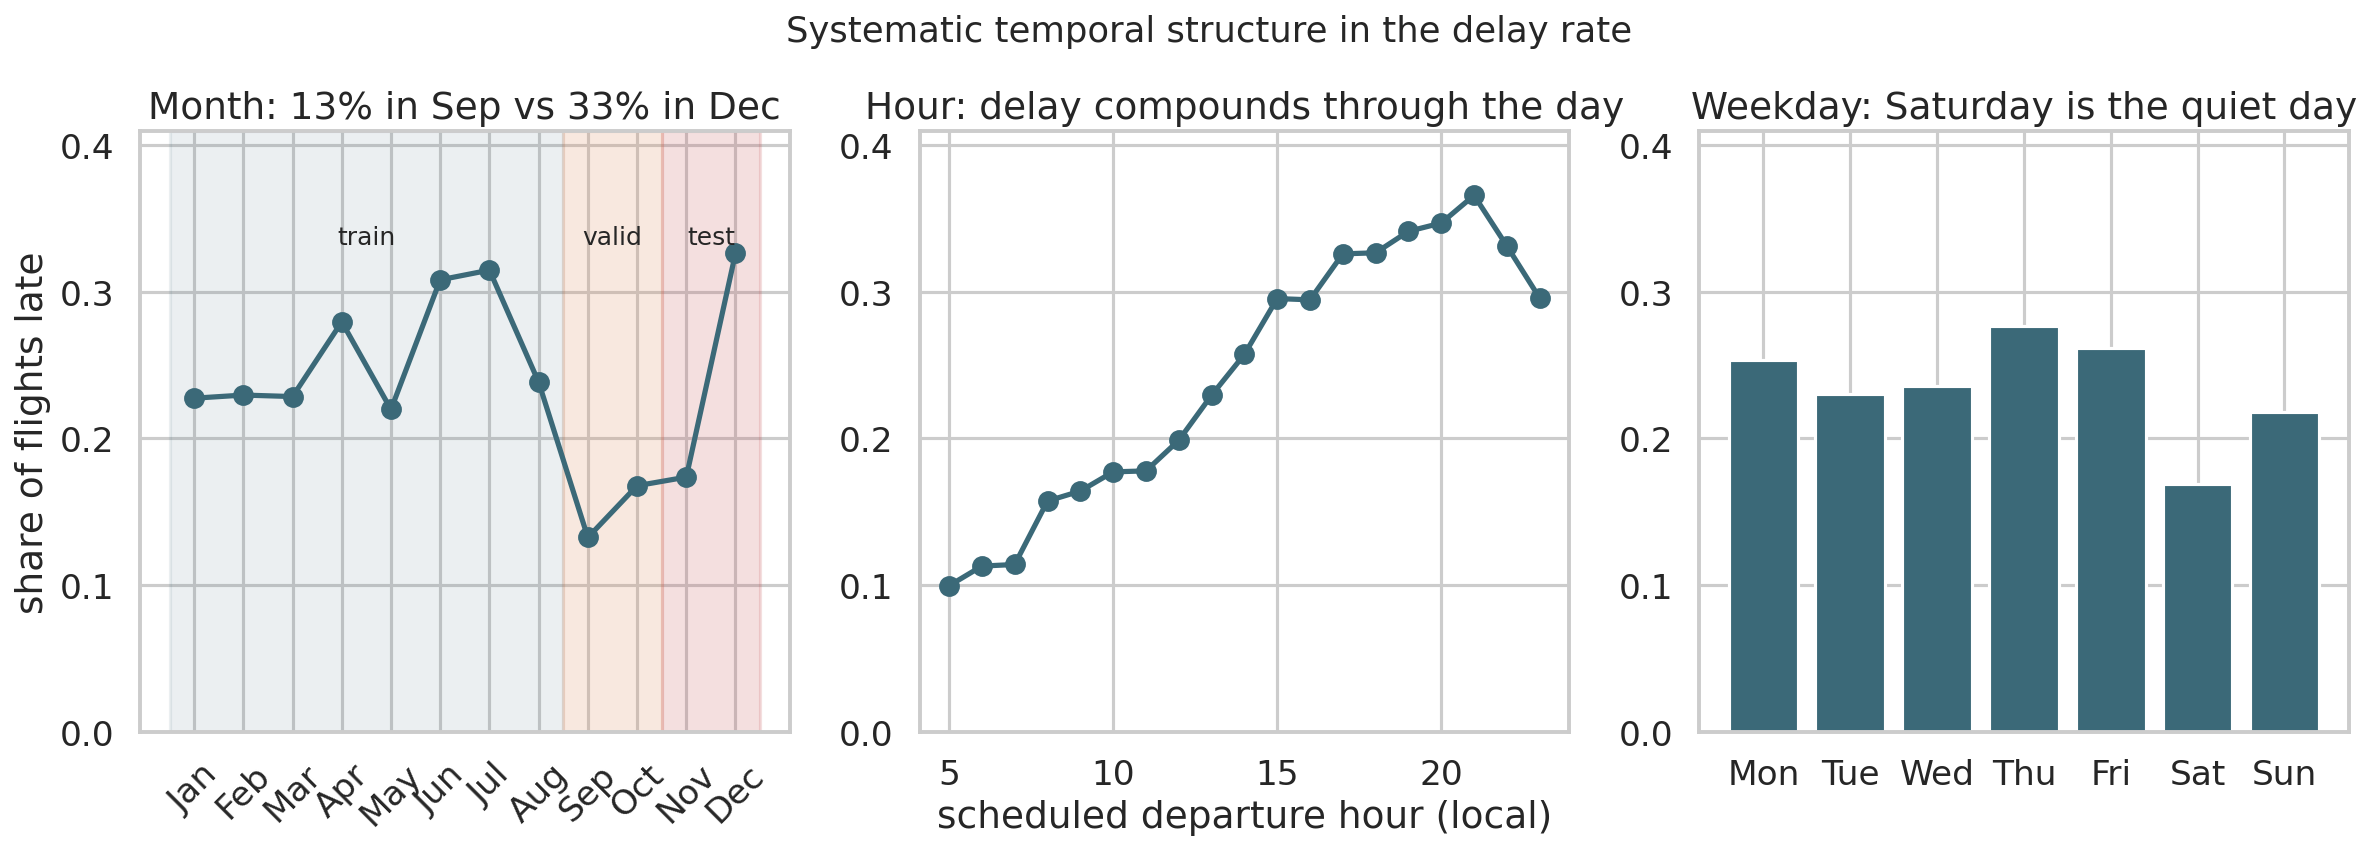

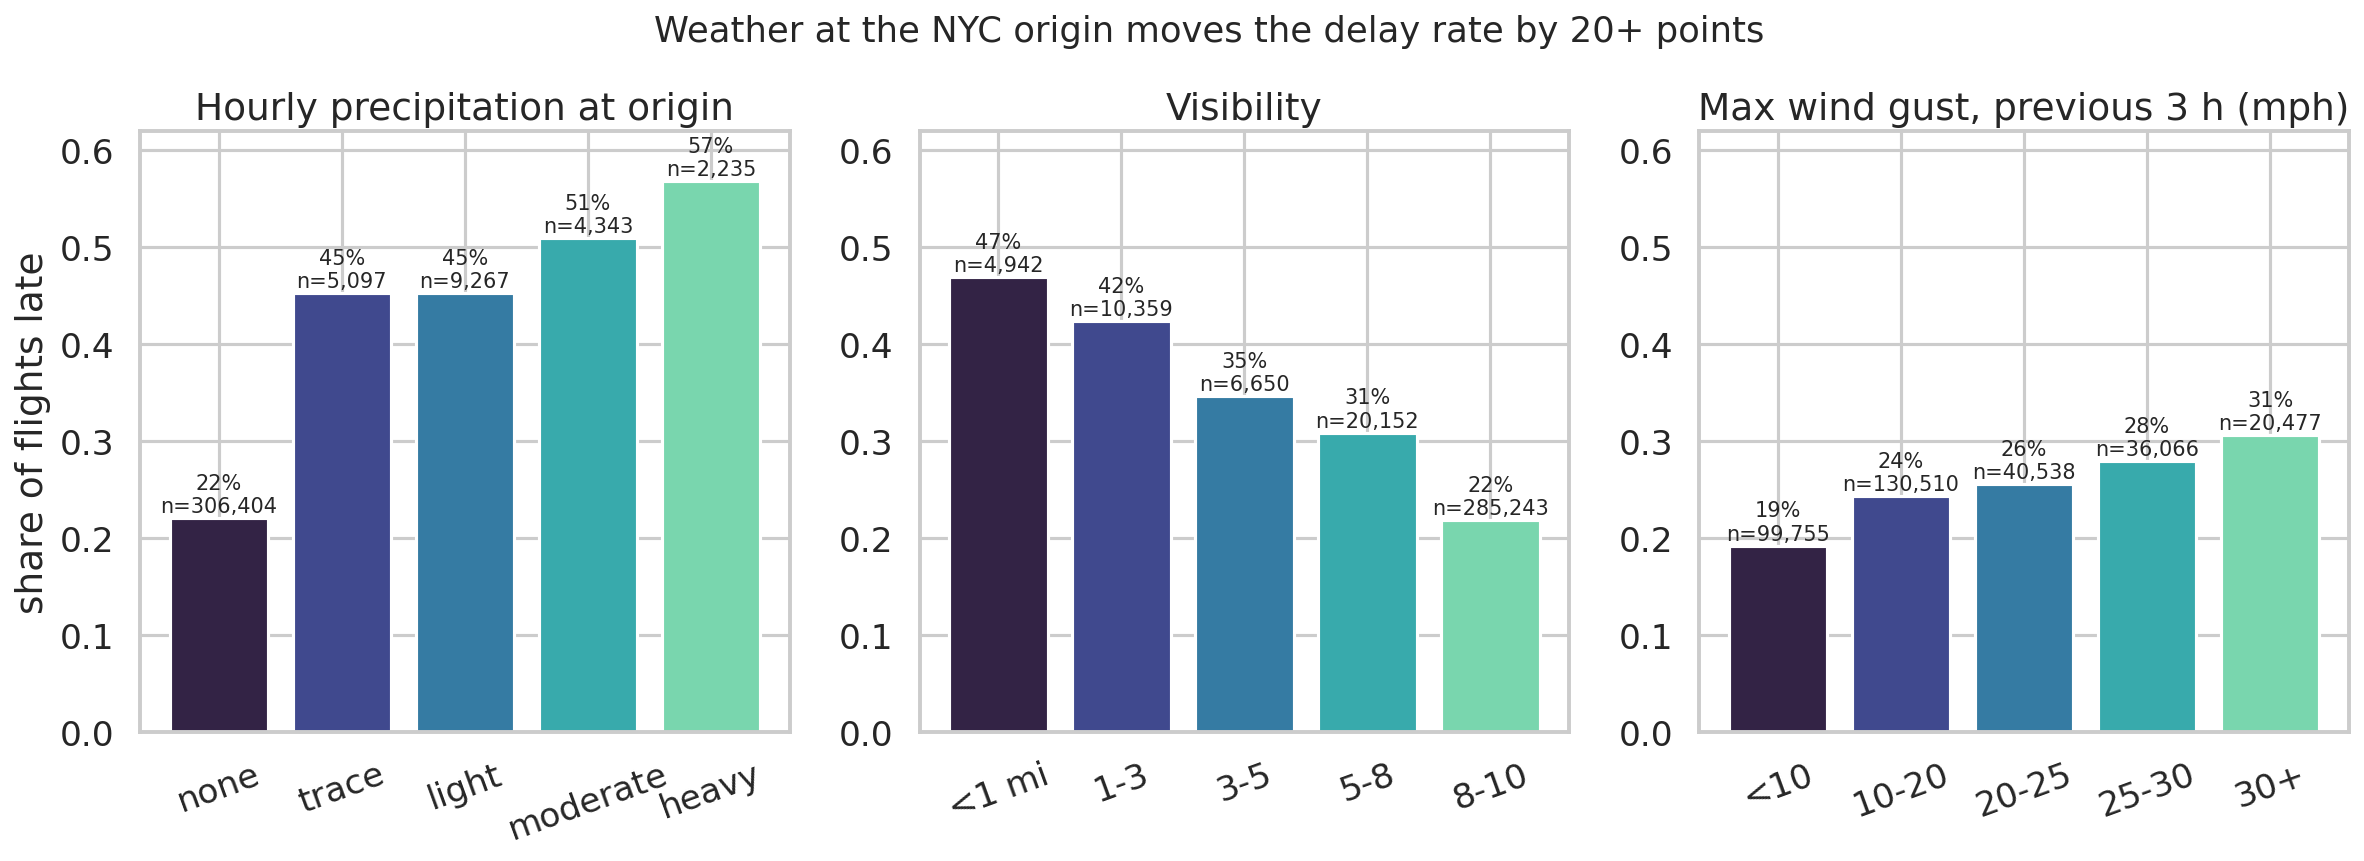

In [7]:
display(Image("../reports/figures/02_temporal_patterns.png"))
display(Image("../reports/figures/04_weather_effects.png"))

In [8]:
full = pd.concat([train, valid, test])
pd.DataFrame({
    "dry hours":            [f"{full.loc[full.wx_precip == 0, 'is_delayed'].mean():.1%}"],
    "any precipitation":    [f"{full.loc[full.wx_precip > 0, 'is_delayed'].mean():.1%}"],
    "visibility >= 3 mi":   [f"{full.loc[full.wx_visib >= 3, 'is_delayed'].mean():.1%}"],
    "visibility < 3 mi":    [f"{full.loc[full.wx_visib < 3, 'is_delayed'].mean():.1%}"],
}, index=["late rate"]).T

,late rate
dry hours,22.1%
any precipitation,47.7%
visibility >= 3 mi,22.9%
visibility < 3 mi,45.5%


### The rotation feature we had to fix

The dataset records only *departures* from NYC, so an aircraft's return leg into
New York is invisible. Measuring turnaround as the gap since the previous leg's
scheduled arrival therefore spans an entire unobserved round trip. Subtracting
the previous block time recovers the real schedule slack.

In [9]:
bands = pd.cut(full.rotation_slack_min, [-1e9, 0, 45, 90, 180, 1e9],
               labels=["negative", "0-45 m", "45-90", "90-180", "180 m+"])
full.groupby(bands, observed=True).agg(
    late_rate=("is_delayed", "mean"), flights=("is_delayed", "size")).round(3)

,late_rate,flights
rotation_slack_min,,
negative,0.785,1620
0-45 m,0.508,3928
45-90,0.293,36282
90-180,0.266,27054
180 m+,0.348,9878


## 5. Held-out results

In [10]:
results = json.load(open("../reports/metrics/evaluation.json"))
rows = []
for k in ["prior", "historical_rate", "logistic_regression", "random_forest",
          "xgboost", "lightgbm", "lightgbm_gate"]:
    t = results[k]["test"]
    rows.append({"model": k, "PR-AUC": round(t["pr_auc"], 4),
                 "ROC-AUC": round(t["roc_auc"], 4), "Brier": round(t["brier"], 4)})
pd.DataFrame(rows).set_index("model")

,PR-AUC,ROC-AUC,Brier
model,,,
prior,0.2499,0.5000,0.1875
historical_rate,0.3395,0.6208,0.1815
logistic_regression,0.4775,0.7079,0.1655
random_forest,0.4914,0.7125,0.1642
xgboost,0.5083,0.7157,0.1665
lightgbm,0.5070,0.7156,0.1673
lightgbm_gate,0.8460,0.9026,0.0972


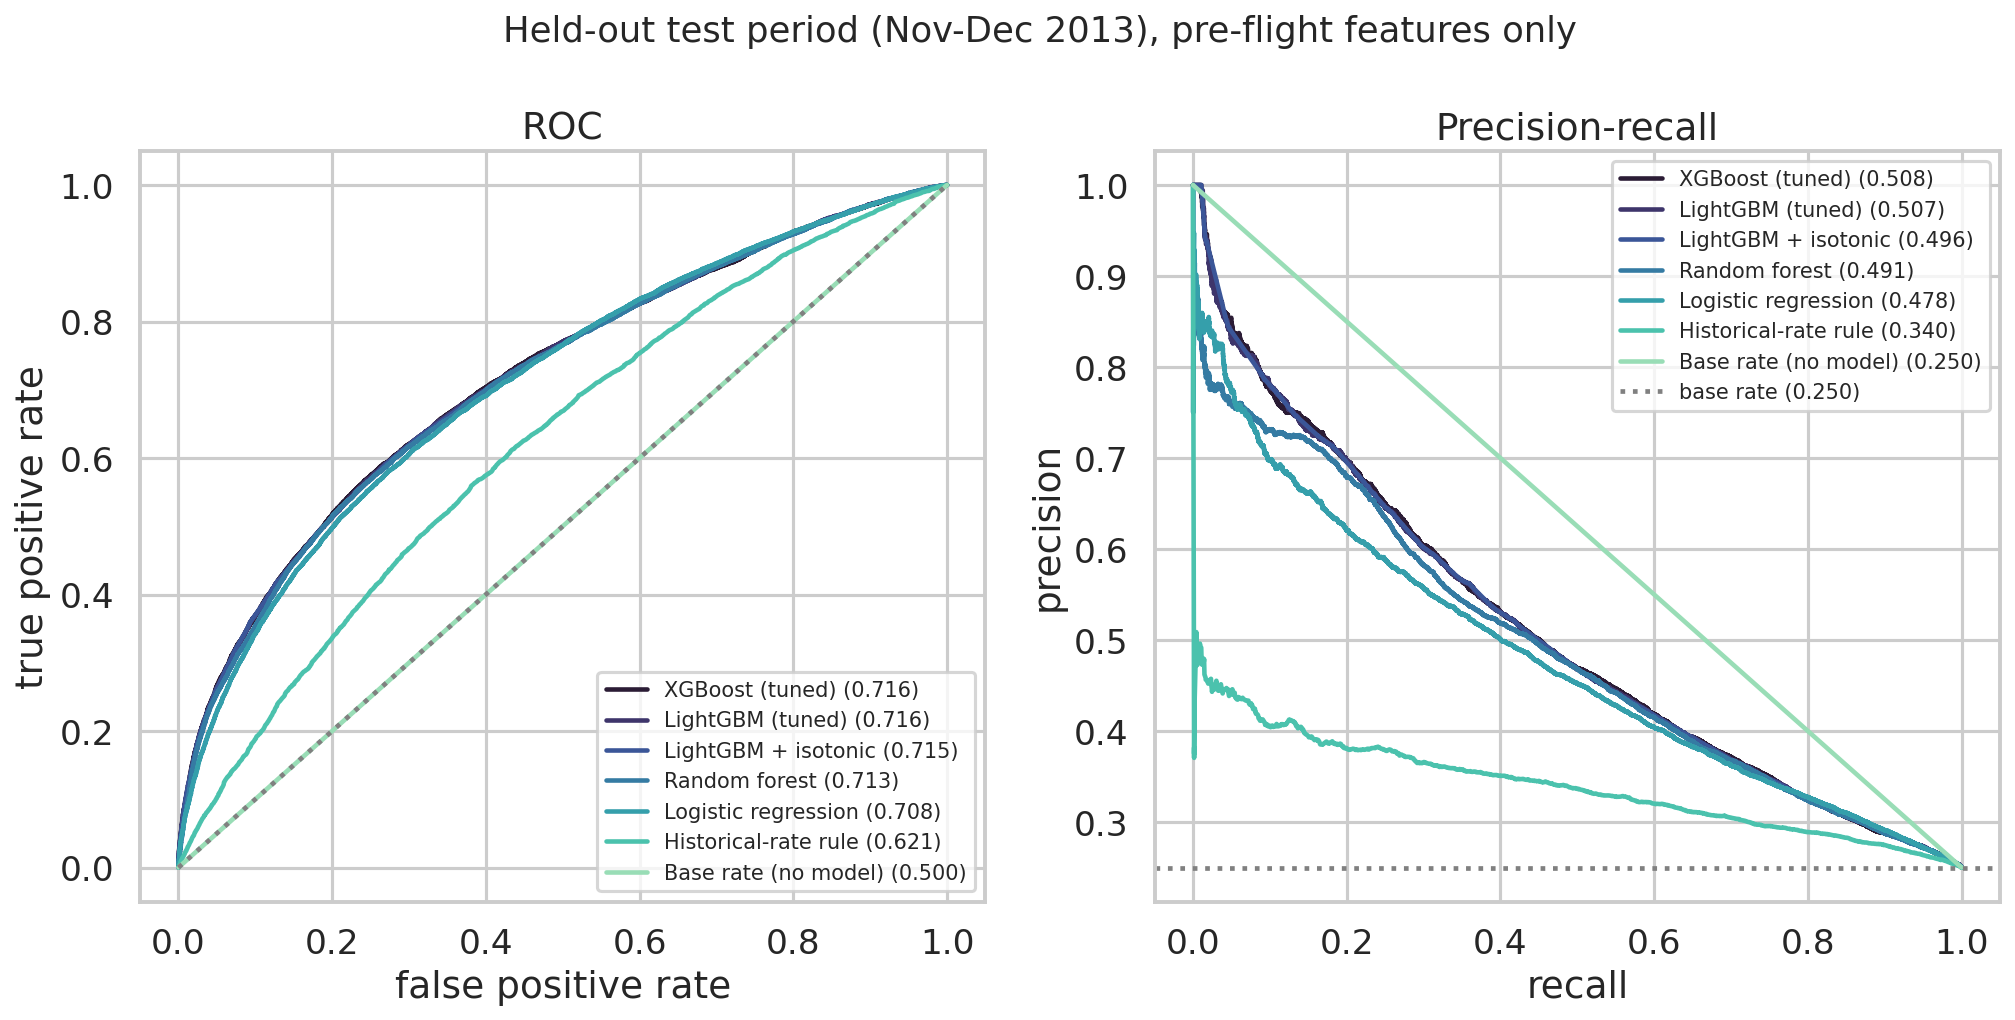

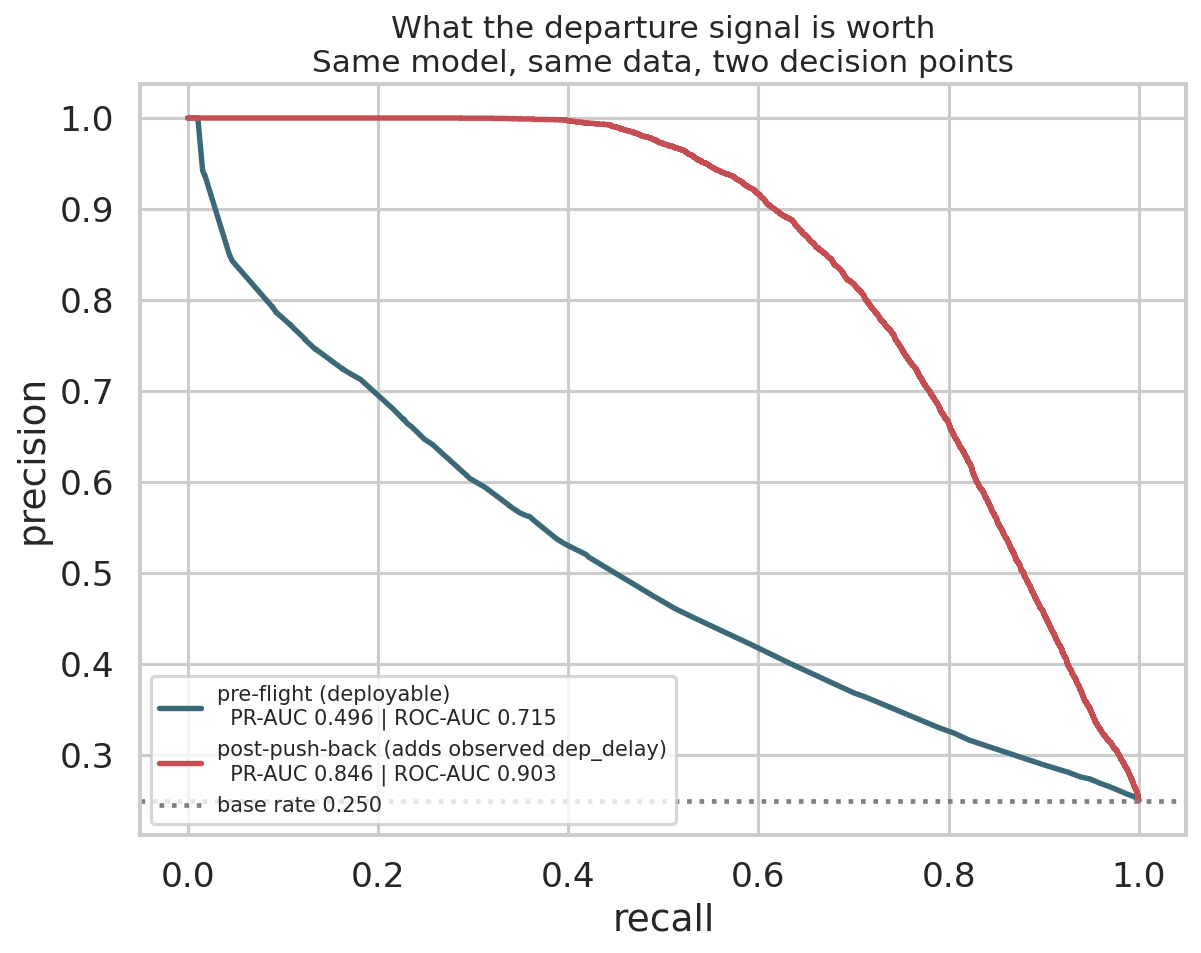

In [11]:
display(Image("../reports/figures/08_roc_pr_curves.png"))
display(Image("../reports/figures/13_prediction_horizon.png"))

Adding the observed departure delay lifts PR-AUC from 0.507 to 0.846.
Most of the apparent skill of a "flight delay model" is the observation that the
plane left late — which is not available when the decision has to be made.

## 6. From probability to decision

In [12]:
d = results["decision"]
pd.Series({
    "threshold chosen on validation": d["threshold_chosen_on_validation"],
    "precision at that threshold":    round(d["test_at_chosen_threshold"]["precision"], 3),
    "recall at that threshold":       round(d["test_at_chosen_threshold"]["recall"], 3),
    "cost per flight":                round(d["test_at_chosen_threshold"]["cost_per_flight"], 3),
    "cost at the default 0.5":        round(d["cost_at_default_0.5"], 3),
    "cost of alerting on nothing":    round(d["cost_of_alerting_nothing"], 3),
    "cost of alerting on everything": round(d["cost_of_alerting_everything"], 3),
}).to_frame("value")

,value
threshold chosen on validation,0.200
precision at that threshold,0.473
recall at that threshold,0.492
cost per flight,0.645
cost at the default 0.5,0.844
cost of alerting on nothing,1.000
cost of alerting on everything,0.750


In [13]:
c = results["capacity"]
print(f"Top {c['k']:.0%} of flights by predicted risk: {c['n_flights_flagged']:,} flights")
print(f"  precision {c['precision_at_k']:.1%}  |  lift {c['lift']:.2f}x over the base rate")

Top 10% of flights by predicted risk: 5,399 flights
  precision 64.1%  |  lift 2.57x over the base rate


## 7. What the model uses, and what it is worth

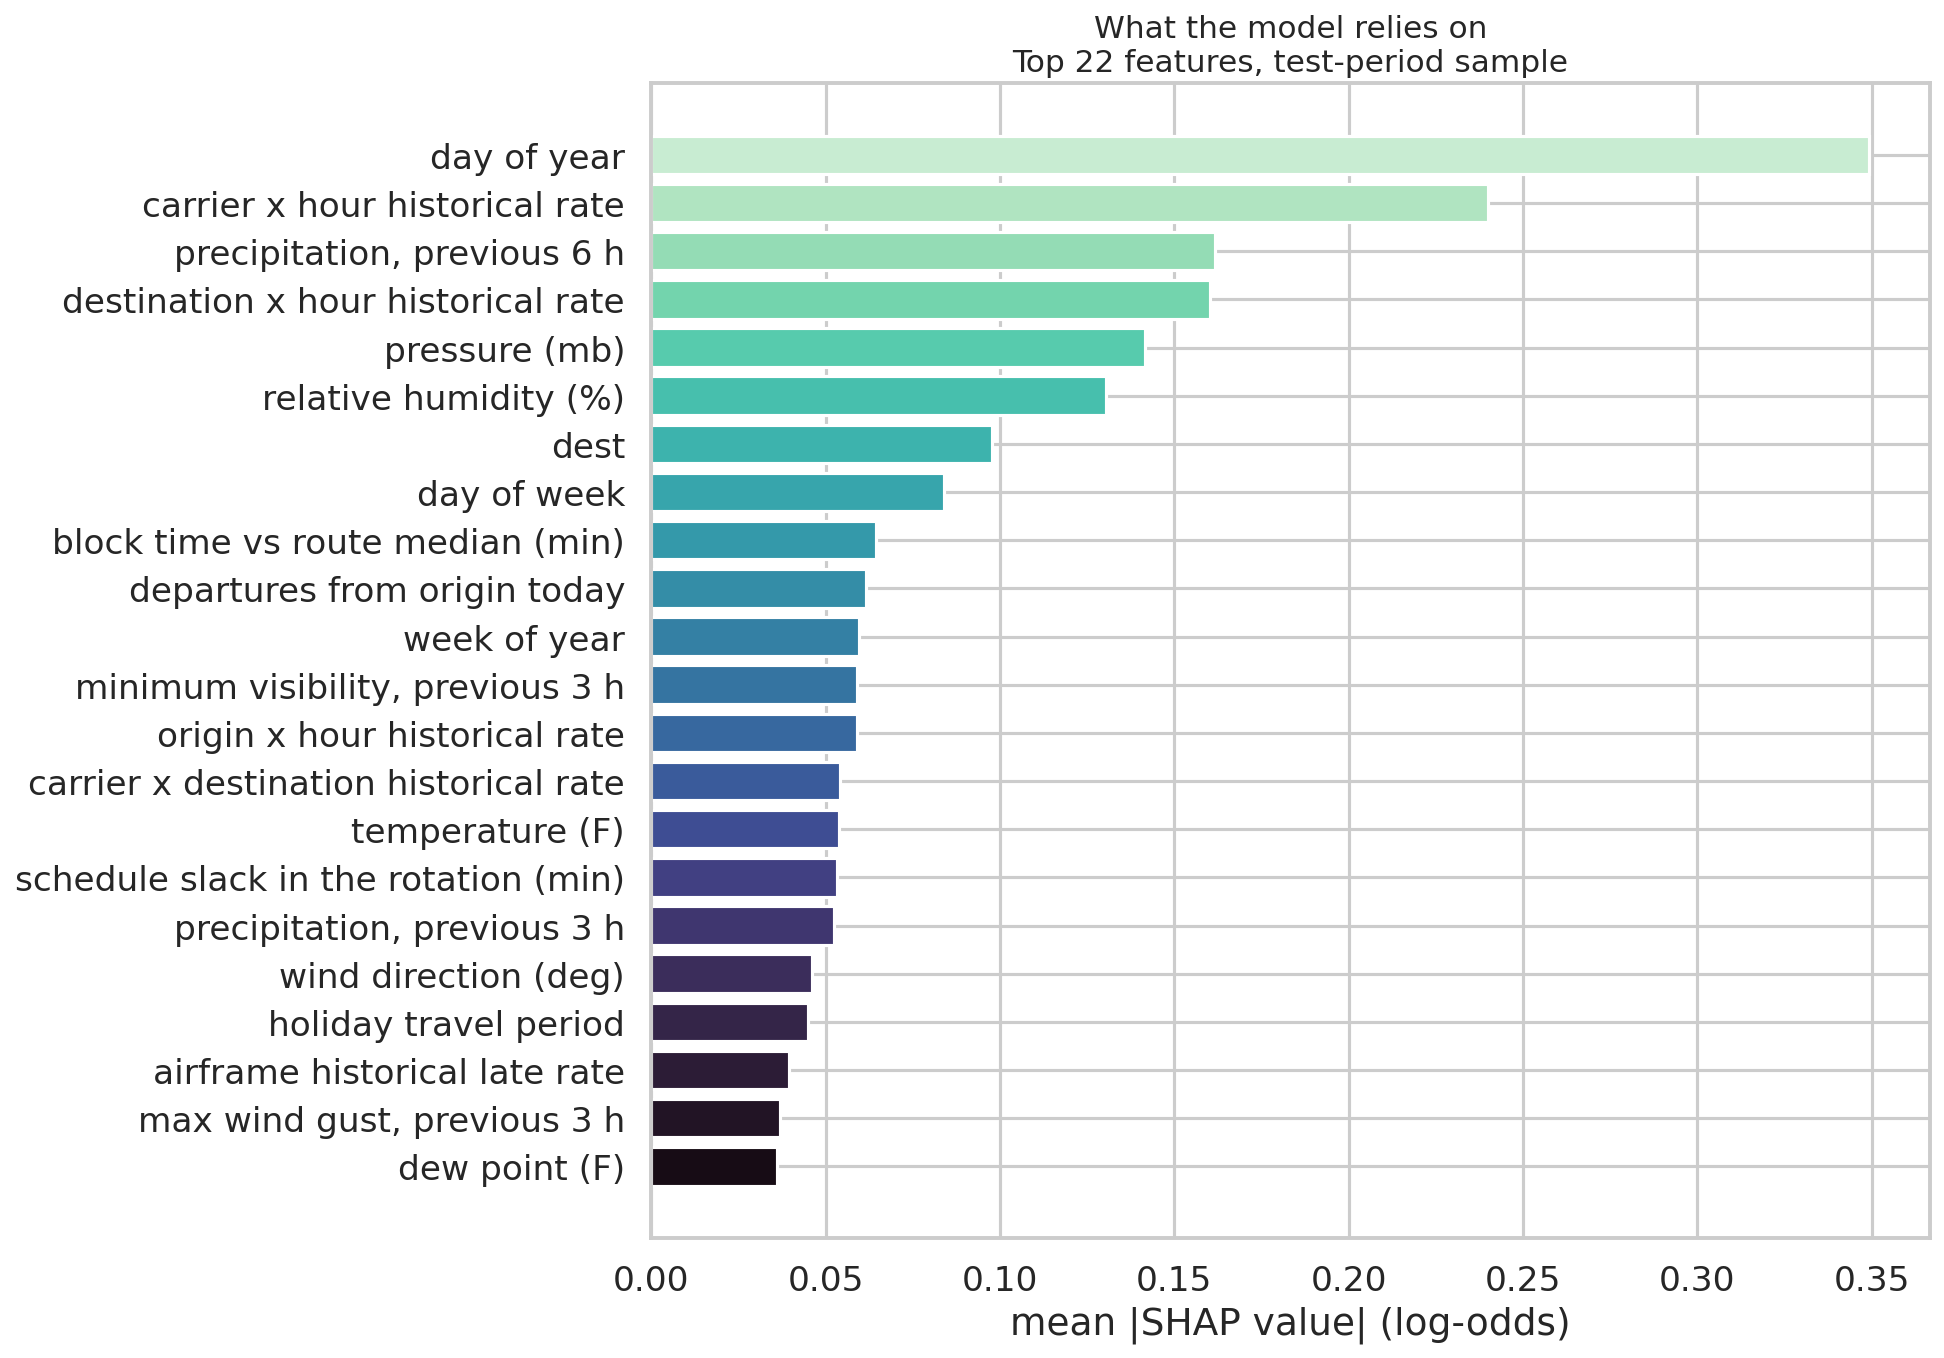

In [14]:
display(Image("../reports/figures/16_shap_importance.png"))

In [15]:
abl = json.load(open("../reports/metrics/ablation.json"))
full_ap = abl["full model"]["test_pr_auc"]
pd.DataFrame([
    {"family removed": k, "test PR-AUC": round(v["test_pr_auc"], 4),
     "change": round(v["test_pr_auc"] - full_ap, 4)}
    for k, v in abl.items() if k != "full model"
]).sort_values("change").set_index("family removed")

,test PR-AUC,change
family removed,,
weather,0.3640,-0.1409
time index (day/week/month),0.4889,-0.0160
rotation,0.4961,-0.0088
calendar,0.4980,-0.0069
route & schedule,0.5034,-0.0015
historical rates,0.5058,0.0009
congestion,0.5070,0.0021
aircraft,0.5073,0.0024


Weather is worth ten times more than anything else. The eight historical-rate
target encodings — which SHAP credits with 24% of influence — are worth nothing:
removing them improves the held-out score. Attribution measures what the fitted
model leans on; only an ablation measures what the data is worth.

## 8. Calibration under seasonal shift

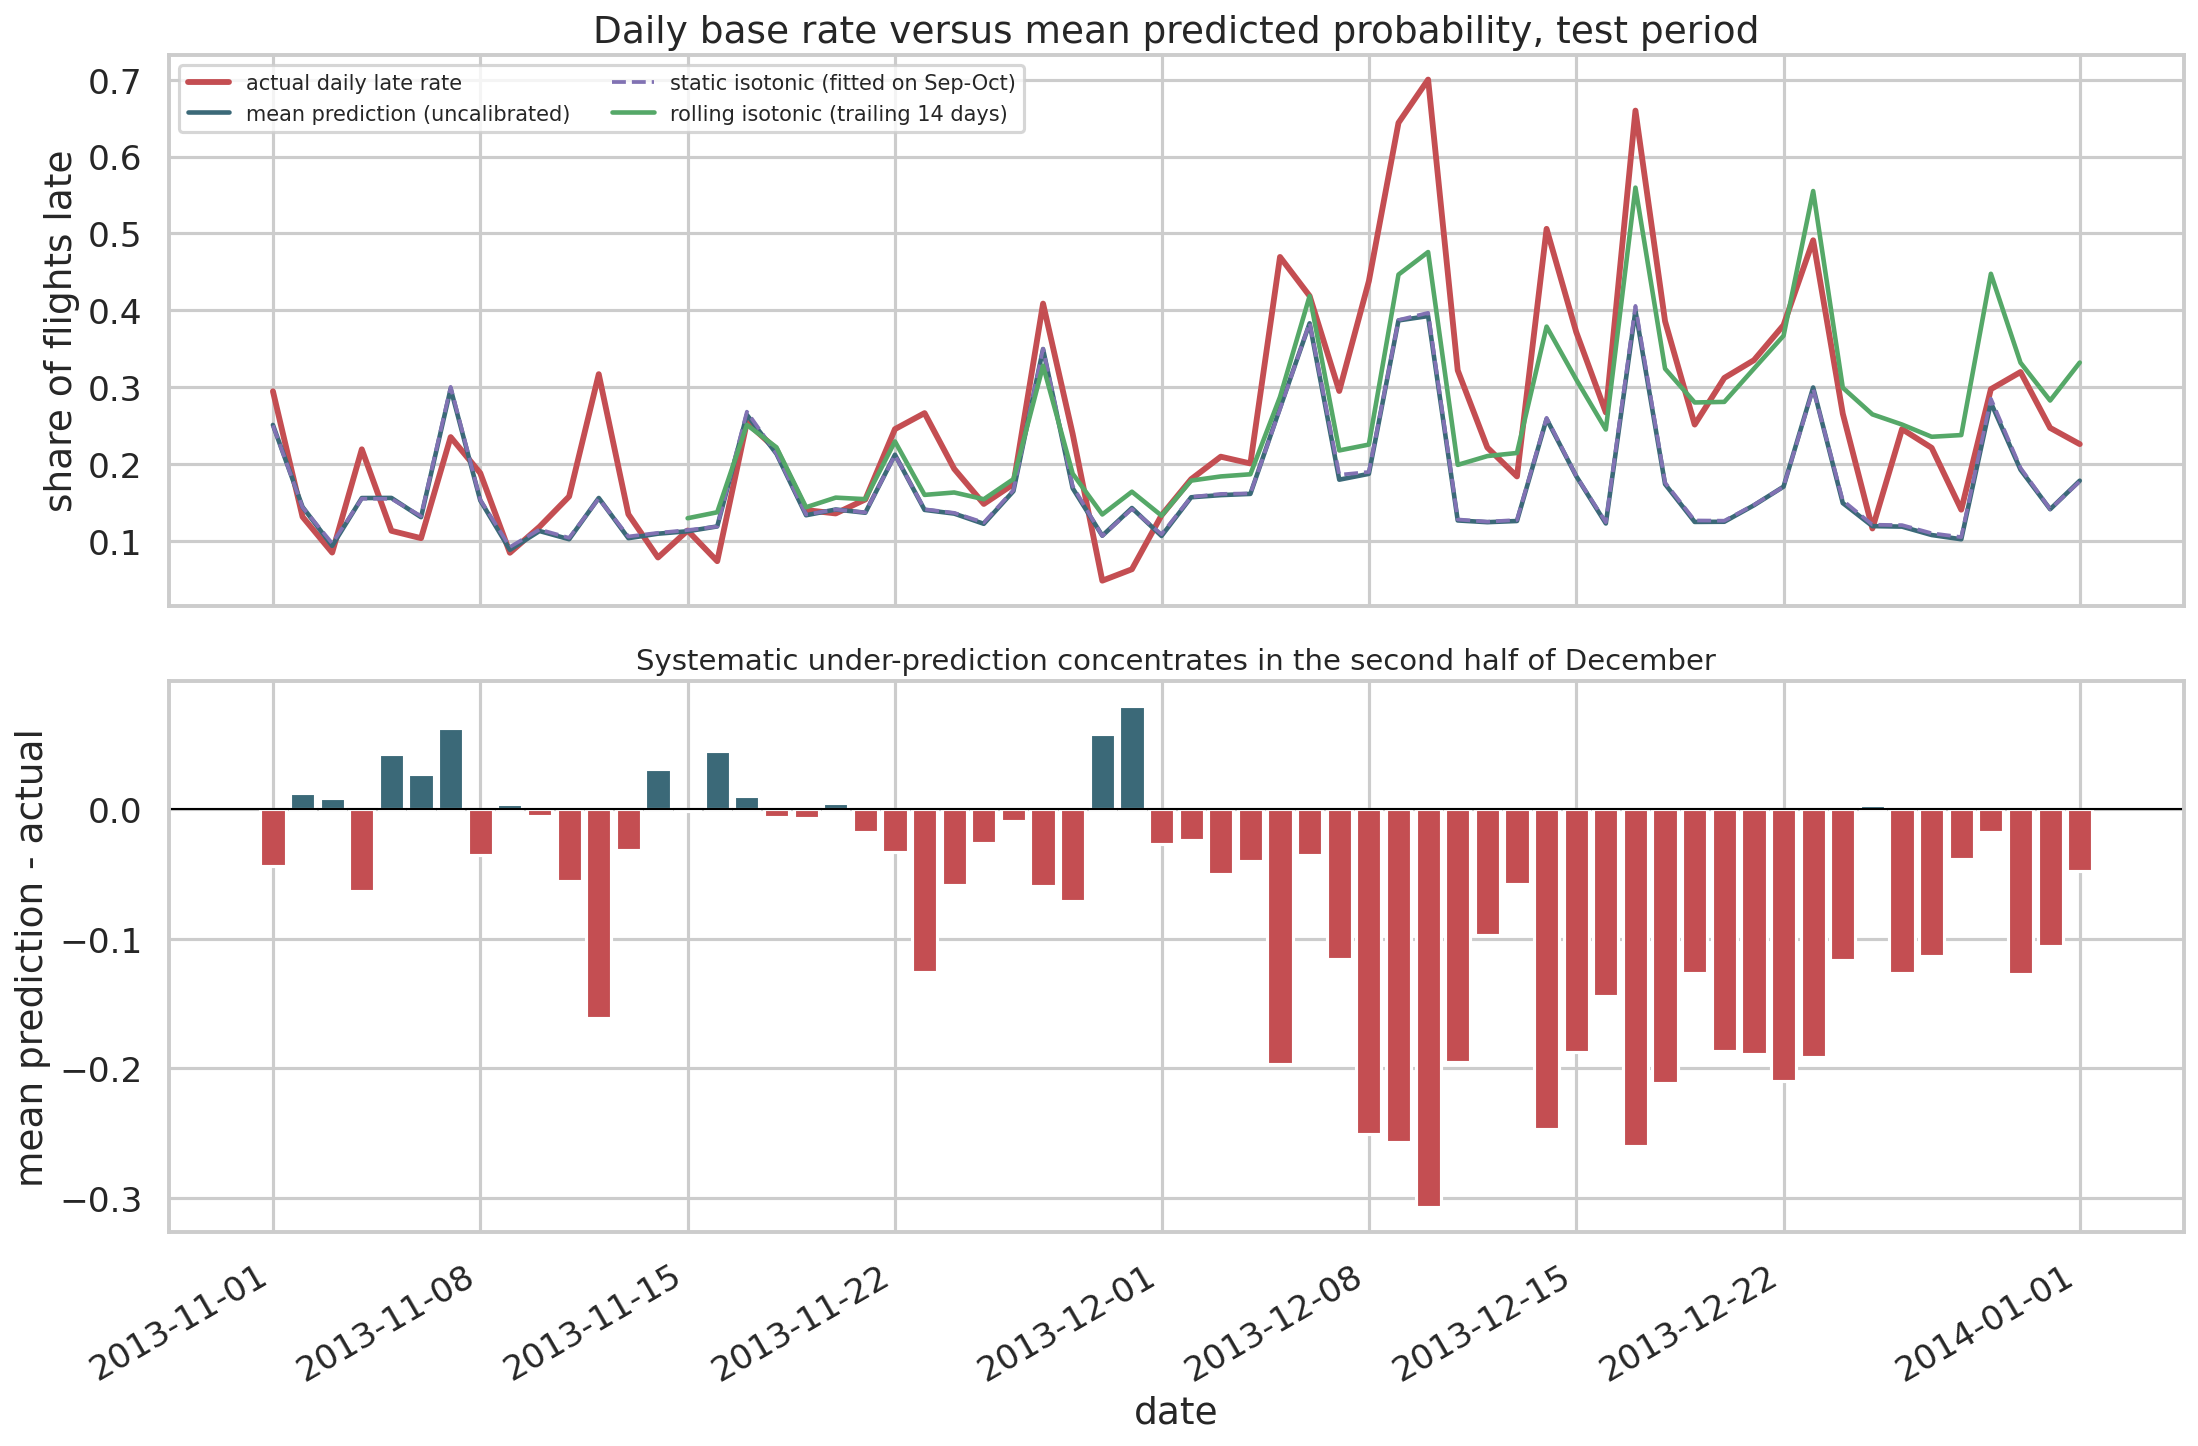

,Brier,mean prediction
uncalibrated,0.1801,0.1832
isotonic_fitted_on_validation,0.1800,0.1846
isotonic_rolling_14d,0.1698,0.2594


In [16]:
display(Image("../reports/figures/15_calibration_drift.png"))
r = results["recalibration"]
pd.DataFrame(r["brier"], index=["Brier"]).T.join(
    pd.DataFrame(r["mean_prediction_vs_actual"], index=["mean prediction"]).T
).round(4)

The model tracks November closely and under-predicts December by a wide
margin. The cause is `day_of_year`: every test value lies outside the training
range, so it applies a near-constant −0.35 log-odds offset to all 54,000 test
flights. Refitting an isotonic calibrator on a trailing 14-day window each day
cuts the Brier score by 5.7% and pulls the mean prediction from 0.183 to 0.259
against an actual 0.276.

**For this problem the maintenance burden is recalibration, not retraining.**

## 9. Explaining one flight

In [17]:
import joblib, shap
from src.config import MODELS
from src.explain import pretty

clf = joblib.load(MODELS / "lightgbm.joblib")
X, y = xy(test, feats)
p = clf.predict_proba(X)[:, 1]

i = int(np.argmax(p))
row = test.iloc[i]
print(f"{row.carrier}{int(row.flight)}  {row.origin}->{row.dest}  {row.flight_date.date()}")
print(f"predicted risk {p[i]:.0%}  |  actually arrived {row.arr_delay:+.0f} min")

sv = shap.TreeExplainer(clf).shap_values(X.iloc[[i]])
sv = sv[1] if isinstance(sv, list) else sv
s = pd.Series(sv[0], index=X.columns)
s = s.reindex(s.abs().sort_values(ascending=False).index[:8])
s.index = [pretty(c) for c in s.index]
s.to_frame("effect on log-odds").round(3)

B61185  JFK->RDU  2013-12-30
predicted risk 98%  |  actually arrived +128 min


,effect on log-odds
schedule slack in the rotation (min),3.132
gap since previous NYC leg (min),1.387
carrier x hour historical rate,0.461
day of year,-0.366
destination x hour historical rate,0.242
dest,0.104
block time vs route median (min),0.077
airframe historical late rate,0.071


## 10. Try it interactively

```bash
make app
```

Single-flight risk with its explanation, an operations-desk view that ranks a
whole day against a fixed alerting budget, and a model card with the
limitations. Full write-up in `reports/report.md`.